# 05 - Histology Image: Loading & Preprocessing

## Learning objectives
1. Pull the H&E image out of AnnData and inspect its dimensions.
2. Display the high- and low-resolution images.
3. Understand RGB channels, stain variation, tissue background, image scale, spot diameter.
4. Do light preprocessing: bounding-box crop, a color-threshold tissue mask, a
   hematoxylin-like channel, and discuss stain normalization.

## Concept
This is home turf for an imaging person. An H&E image is just an RGB array. The only ST-
specific twist is the **scale-factor** bookkeeping that ties pixels to spots. **No deep
learning here** - we keep it to classic image preprocessing.


In [1]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [2]:
import numpy as np
import matplotlib.pyplot as plt

adata = st.load_adata('adata_qc.h5ad')
lib = st.get_library_id(adata)
sf = st.get_scalefactors(adata)
hires = st.get_image(adata, 'hires')
lowres = st.get_image(adata, 'lowres')
print('hires :', hires.shape, hires.dtype, 'min/max', float(np.min(hires)), float(np.max(hires)))
print('lowres:', lowres.shape, lowres.dtype)


hires : (2000, 1921, 3) float32 min/max 0.019607843831181526 0.7372549176216125
lowres: (600, 576, 3) float32


Image arrays may be `float` in [0, 1] or `uint8` in [0, 255] depending on the loader.
We normalize to `uint8` for OpenCV/skimage convenience.

In [3]:
def to_uint8(img):
    """Return an HxWx3 uint8 copy of an RGB image stored as float[0,1] or uint8."""
    img = np.asarray(img)
    if img.dtype != np.uint8:
        img = (255 * np.clip(img, 0, 1)).astype(np.uint8)
    return img[..., :3]  # drop alpha if present

hires_u8 = to_uint8(hires)
lowres_u8 = to_uint8(lowres)
print('hires_u8:', hires_u8.shape, hires_u8.dtype)


hires_u8: (2000, 1921, 3) uint8


### Display hires vs lowres

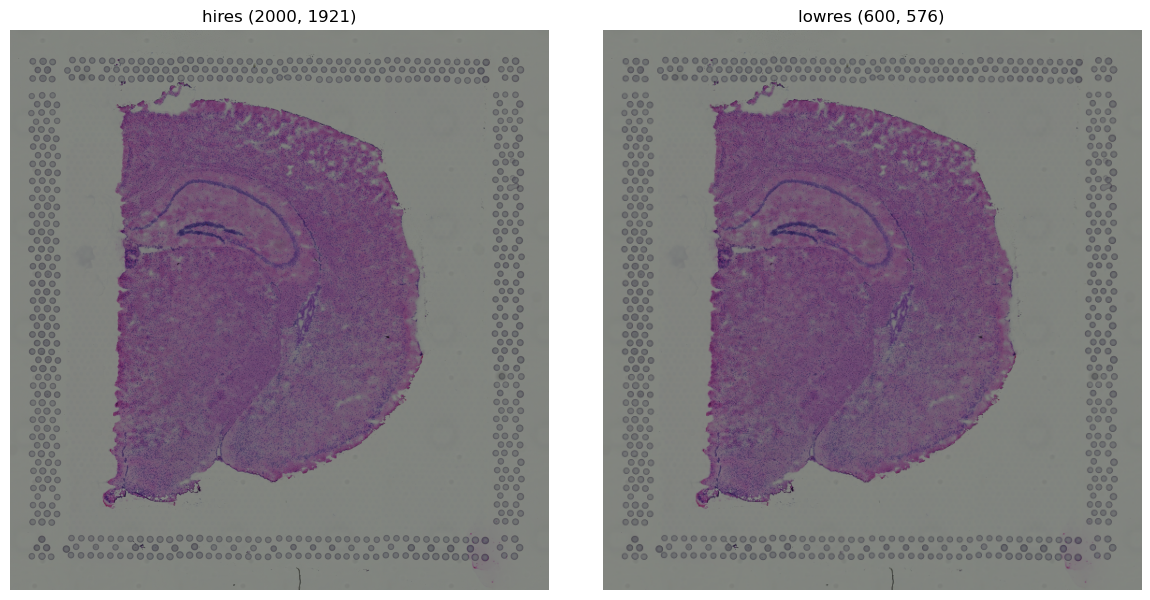

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(hires_u8); axes[0].set_title(f'hires {hires_u8.shape[:2]}'); axes[0].axis('off')
axes[1].imshow(lowres_u8); axes[1].set_title(f'lowres {lowres_u8.shape[:2]}'); axes[1].axis('off')
plt.tight_layout(); plt.show()


### RGB channels & the H&E stain
**Hematoxylin** stains nuclei blue/purple; **eosin** stains cytoplasm/ECM pink. So nuclei-
dense regions look blue and appear darker in the blue-vs-red balance. Let's view channels.

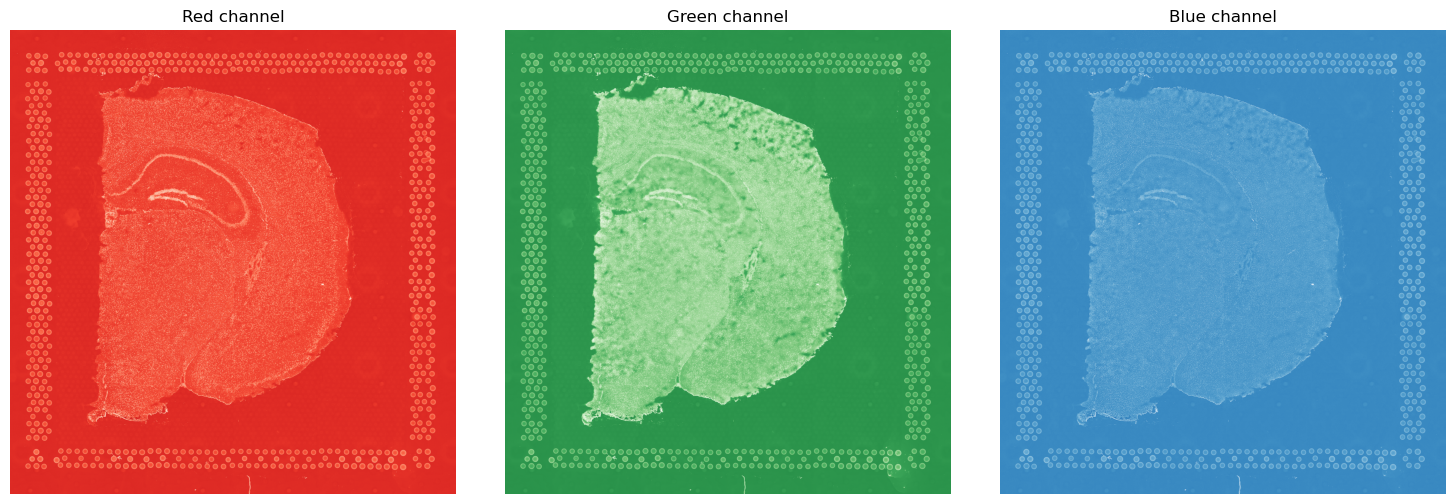

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, cmap) in enumerate([('Red', 'Reds'), ('Green', 'Greens'), ('Blue', 'Blues')]):
    axes[i].imshow(hires_u8[..., i], cmap=cmap)
    axes[i].set_title(f'{name} channel'); axes[i].axis('off')
plt.tight_layout(); plt.show()


### Image scale & spot diameter (the only ST-specific bit)
Spot coordinates are full-resolution pixels; the hires image is downscaled by
`tissue_hires_scalef`. The spot diameter in **hires** pixels is
`spot_diameter_fullres * tissue_hires_scalef` - we will reuse this exact number to size
image patches in notebook 09.

In [6]:
scalef = sf['tissue_hires_scalef']
spot_diam_hires = sf['spot_diameter_fullres'] * scalef
print(f'tissue_hires_scalef      : {scalef:.5f}')
print(f'spot_diameter_fullres    : {sf["spot_diameter_fullres"]:.1f} px (full-res)')
print(f'spot diameter in hires px: {spot_diam_hires:.1f}')


tissue_hires_scalef      : 0.17011
spot_diameter_fullres    : 89.4 px (full-res)
spot diameter in hires px: 15.2


### Tissue mask via color thresholding
Background is bright/white; tissue is stained (lower brightness, more saturation). A simple
saturation/brightness threshold in HSV separates tissue from glass - the histology analogue
of thresholding tissue vs air in CT.

tissue fraction of image: 0.331


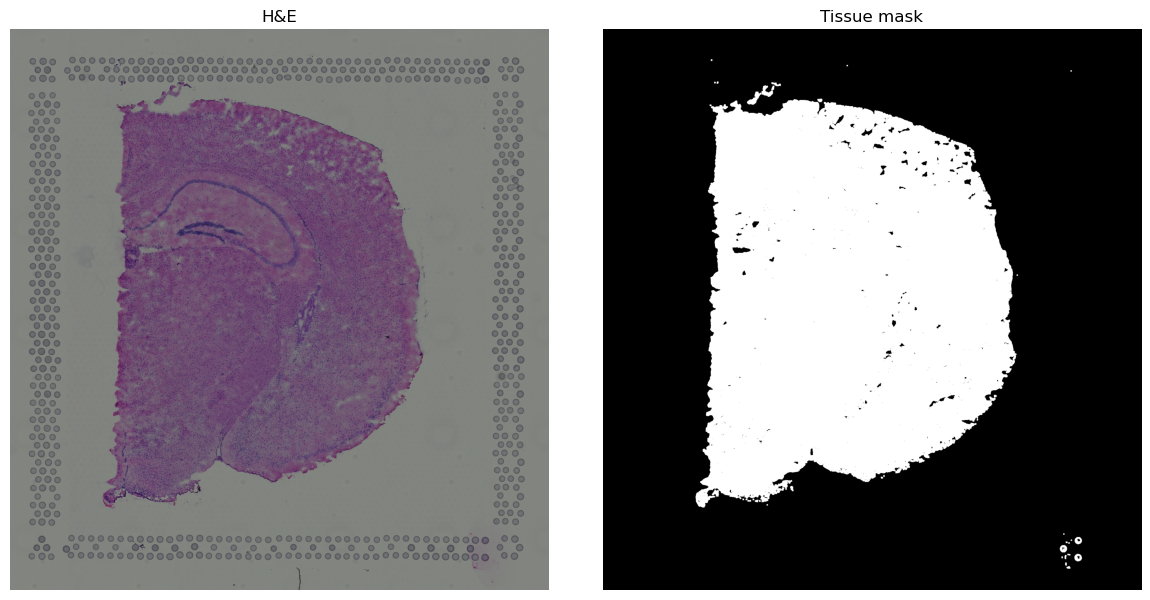

In [7]:
import cv2

hsv = cv2.cvtColor(hires_u8, cv2.COLOR_RGB2HSV)
sat = hsv[..., 1]                         # saturation: tissue > background
val = hsv[..., 2]                         # brightness: background near 255
tissue_mask = (sat > 20) & (val < 230)
# Clean up speckle with a morphological opening.
kernel = np.ones((5, 5), np.uint8)
tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(bool)
print('tissue fraction of image:', round(float(tissue_mask.mean()), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(hires_u8); axes[0].set_title('H&E'); axes[0].axis('off')
axes[1].imshow(tissue_mask, cmap='gray'); axes[1].set_title('Tissue mask'); axes[1].axis('off')
plt.tight_layout(); plt.show()


### Bounding-box crop
Crop to the tissue's bounding box to drop empty glass (saves compute, like cropping a CT
to the body).

bounding box (y0,y1,x0,x1): (108, 1923, 330, 1706)


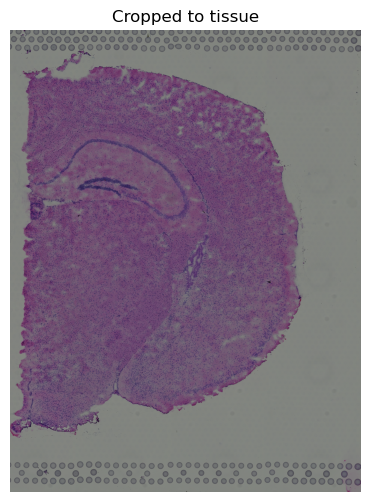

In [8]:
ys, xs = np.where(tissue_mask)
y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
cropped = hires_u8[y0:y1, x0:x1]
print('bounding box (y0,y1,x0,x1):', (int(y0), int(y1), int(x0), int(x1)))
plt.figure(figsize=(6, 6)); plt.imshow(cropped); plt.title('Cropped to tissue'); plt.axis('off'); plt.show()


### Hematoxylin-like channel (color deconvolution)
`skimage.color.rgb2hed` separates **H**ematoxylin / **E**osin / **D**AB. The H channel
approximates nuclear density - a biologically meaningful 'stain-aware grayscale' we will
turn into features later.

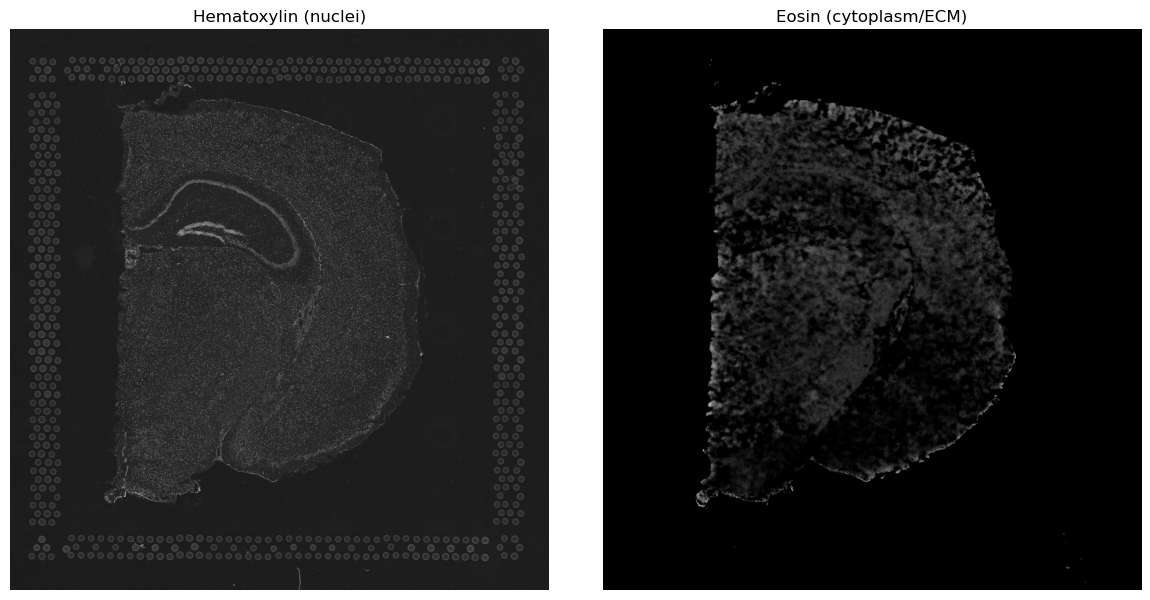

In [9]:
from skimage.color import rgb2hed

hed = rgb2hed(hires_u8 / 255.0)
hema = hed[..., 0]  # hematoxylin (nuclei)
eosin = hed[..., 1] # eosin (cytoplasm/ECM)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(hema, cmap='gray'); axes[0].set_title('Hematoxylin (nuclei)'); axes[0].axis('off')
axes[1].imshow(eosin, cmap='gray'); axes[1].set_title('Eosin (cytoplasm/ECM)'); axes[1].axis('off')
plt.tight_layout(); plt.show()


### Stain normalization (discussion)
Different slides/scanners produce different color casts (batch effects), just like scanner-
dependent intensity drift in MRI/CT. **Stain normalization** (e.g. Macenko or Reinhard)
maps an image to a reference stain profile so features are comparable across slides. For a
single-section tutorial it is unnecessary, but for multi-sample pharma cohorts it is
essential before extracting image features. (We note it rather than implement a full
method here.)

## Common pitfalls
- Mixing float[0,1] and uint8 images - normalize first (`to_uint8`).
- OpenCV expects **BGR**; our arrays are **RGB** - convert with the right flag.
- Thresholds are slide-specific; inspect the mask before trusting it.

## Interpretation
You can load, display, mask, crop, and stain-separate the H&E - all the pieces needed to
extract per-spot image features later.

## What this means biologically
The hematoxylin channel highlights where nuclei (cells) are dense; eosin highlights
cytoplasm/extracellular matrix. These morphological cues are what a pathologist reads, and
what we will correlate with gene expression.

---
**Next:** `06_spatial_visualization.ipynb`.
